In [1]:
import os
# This prevents the most common VS Code PyTorch kernel crash
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from d2l import torch as d2l

d2l.use_svg_display()

transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
sample_loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True,num_workers=0)
images, labels = next(iter(sample_loader))
print(f"Input Imaage Shape: {images.shape}")


100%|██████████| 170M/170M [01:11<00:00, 2.38MB/s] 


Input Imaage Shape: torch.Size([1, 3, 32, 32])


In [5]:
class simple(nn.Module):
    def __init__(self):
        super(simple, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=1, padding=0)

    def forward(self, x):
        return self.conv1(x)



class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return x
    


class dilation(nn.Module):
    def __init__(self):
        super(dilation, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=0, dilation=3)

    def forward(self, x):
        return self.conv1(x)




In [6]:
simple = simple()
VGG = VGG()
dilation = dilation()

out_simple = simple(images)
out_VGG = VGG(images)
out_dilation = dilation(images)

print(f"Original Input Shape:  {images.shape}")
print("-"*50)
print(f"Old architecture Output:  {out_simple.shape}")
print(f"VGG Stacked Output:  {out_VGG.shape}")
print(f"Dilated Params Output:  {out_dilation.shape}")
print("-" * 50)

print(f"Simple architecture parameter count:  {sum(p.numel() for p in simple.parameters())}")
print(f"Stacked VGG parameter count:  {sum(p.numel() for p in VGG.parameters())}")
print(f"dilated parameter count:  {sum(p.numel() for p in dilation.parameters())}")

Original Input Shape:  torch.Size([1, 3, 32, 32])
--------------------------------------------------
Old architecture Output:  torch.Size([1, 64, 26, 26])
VGG Stacked Output:  torch.Size([1, 64, 26, 26])
Dilated Params Output:  torch.Size([1, 64, 26, 26])
--------------------------------------------------
Simple architecture parameter count:  9472
Stacked VGG parameter count:  75648
dilated parameter count:  1792


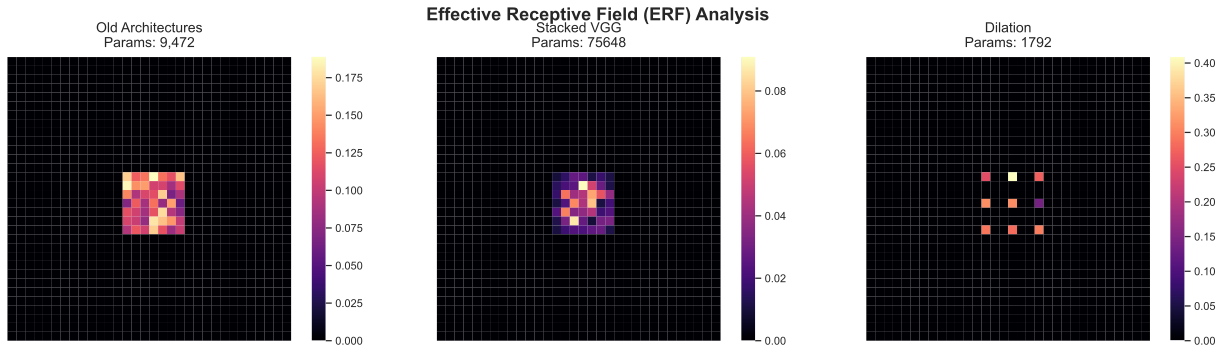

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def compute_erf(model):
    model.eval()

    dummy_input = torch.ones((1, 3, 32, 32), requires_grad=True)

    output = model(dummy_input)
    center_pixel = output[0,0,13,13]

    model.zero_grad()
    center_pixel.backward()
    gradients = dummy_input.grad[0]
    


    heatmap_2d = gradients.abs().sum(dim=0).detach().numpy()
    return heatmap_2d


erf_simple = compute_erf(simple)
erf_VGG = compute_erf(VGG)
erf_dilation = compute_erf(dilation)

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Effective Receptive Field (ERF) Analysis", fontsize=18, fontweight='bold')

def plot_heatmap(data, ax, title):
    sns.heatmap(data, ax=ax, cmap="magma", cbar=True, square=True, 
                xticklabels=False, yticklabels=False)
    ax.set_title(title, fontsize=14, pad=10)

plot_heatmap(erf_simple, axes[0], "Old Architectures\nParams: 9,472")
plot_heatmap(erf_VGG, axes[1], "Stacked VGG\nParams: 75648")
plot_heatmap(erf_dilation, axes[2], "Dilation\nParams: 1792")
plt.tight_layout()
plt.show()

    


